# ARIMA - Air Passenger Forecasting

## Project Overview

This project analyzes and forecasts monthly airline passenger counts using classical **time-series modeling**.

The notebook builds toward ARIMA by examining trend, stationarity, differencing, **ACF/PACF**, and separate **AutoRegressive (AR)** and **Moving Average (MA)** models before training and evaluating an **ARIMA** model.


## 1. Import Required Libraries


In [1]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 2. Load Dataset


In [2]:
df = pd.read_csv("AirPassengers.csv")
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


## 3. Prepare Time Series


In [3]:
df["Month"] = pd.to_datetime(df["Month"])
df = df.sort_values("Month").set_index("Month").asfreq("MS")
df.info()
display(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 144 entries, 1949-01-01 to 1960-12-01
Freq: MS
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  144 non-null    int64
dtypes: int64(1)
memory usage: 2.2 KB


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## 4. Explore Dataset


In [4]:
print("Date range:", df.index.min(), "to", df.index.max())
print("Number of observations:", len(df))
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
display(df.describe())


Date range: 1949-01-01 00:00:00 to 1960-12-01 00:00:00
Number of observations: 144

Missing values:
Passengers    0
dtype: int64

Summary statistics:


,Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


## 5. Time-Series Visualization


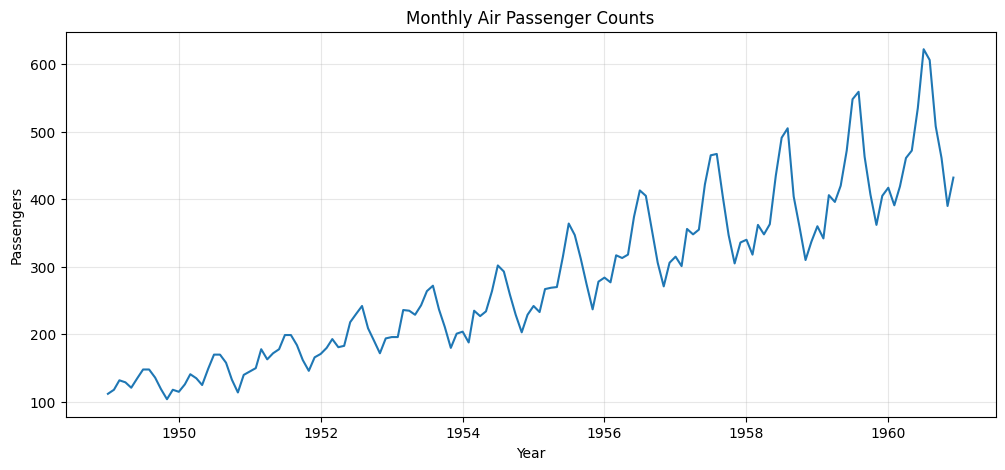

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Passengers"])
plt.title("Monthly Air Passenger Counts")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(alpha=0.3)
plt.show()


## 6. Stationarity Analysis

The **Augmented Dickey-Fuller (ADF) test** is used to test whether the series is stationary.

- Null hypothesis: the series is non-stationary.
- A p-value below 0.05 provides evidence against the null hypothesis.


In [6]:
def adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test - {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.6f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

adf_test(df["Passengers"], "Original Series")


ADF Test - Original Series
ADF Statistic: 0.8154
p-value: 0.991880
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788


## 7. Differencing


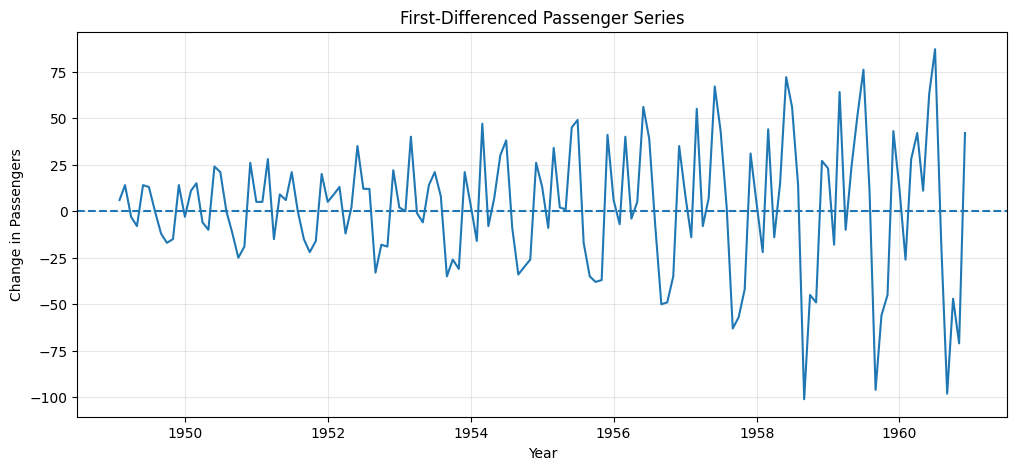

ADF Test - First-Differenced Series
ADF Statistic: -2.8293
p-value: 0.054213
Critical Values:
  1%: -3.4817
  5%: -2.8840
  10%: -2.5788


In [7]:
df["First_Difference"] = df["Passengers"].diff()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["First_Difference"])
plt.axhline(0, linestyle="--")
plt.title("First-Differenced Passenger Series")
plt.xlabel("Year")
plt.ylabel("Change in Passengers")
plt.grid(alpha=0.3)
plt.show()

adf_test(df["First_Difference"], "First-Differenced Series")


## 8. ACF and PACF Analysis

**ACF** measures correlation between the series and its lagged observations. **PACF** measures the direct relationship at each lag after accounting for shorter lags. These plots help identify plausible AR and MA orders.


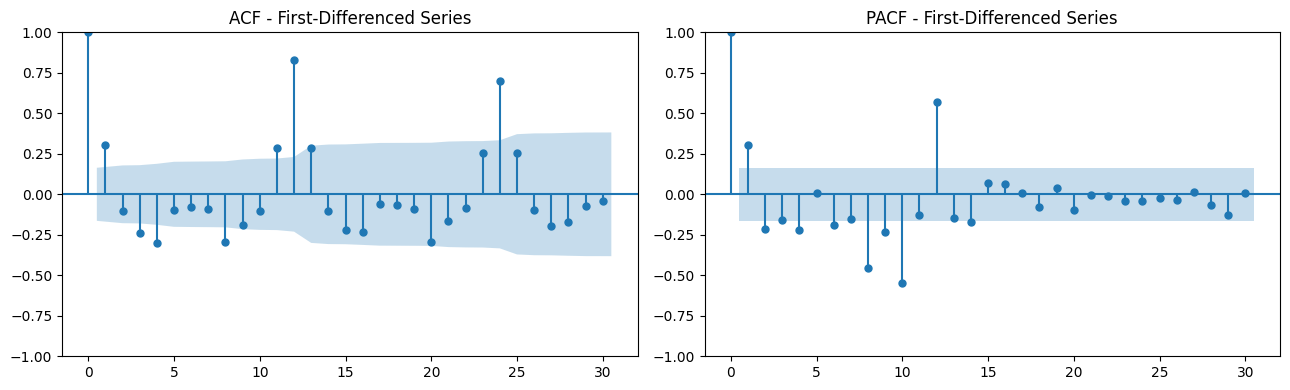

In [8]:
stationary_series = df["First_Difference"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_acf(stationary_series, lags=30, ax=axes[0])
axes[0].set_title("ACF - First-Differenced Series")
plot_pacf(stationary_series, lags=30, method="ywm", ax=axes[1])
axes[1].set_title("PACF - First-Differenced Series")
plt.tight_layout()
plt.show()


## 9. Chronological Train-Test Split


Training observations: 120
Testing observations: 24
Training period: 1949-01-01 00:00:00 to 1958-12-01 00:00:00
Testing period: 1959-01-01 00:00:00 to 1960-12-01 00:00:00


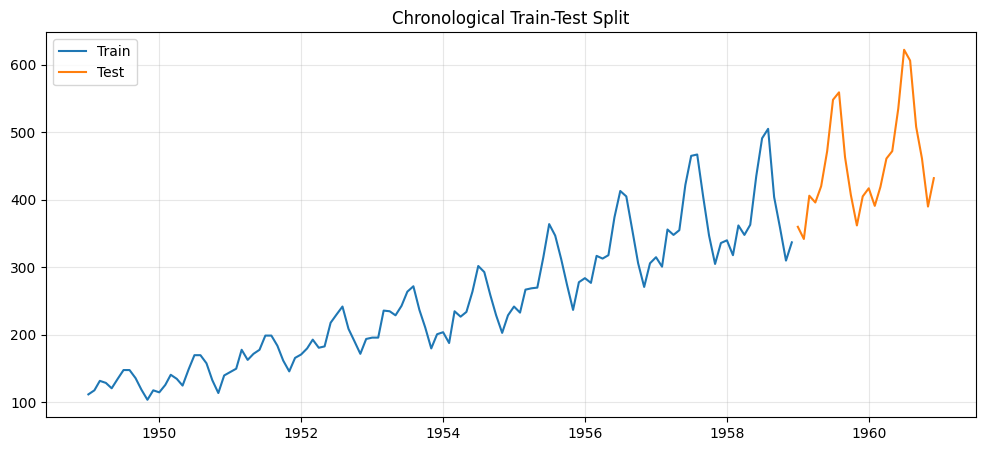

In [9]:
series = df["Passengers"].dropna()
train = series.iloc[:-24]
test = series.iloc[-24:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period:", test.index.min(), "to", test.index.max())

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title("Chronological Train-Test Split")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. AutoRegressive (AR) Model

An AR model predicts current values from previous observations. A 12-lag model is used to demonstrate autoregressive forecasting.


In [10]:
ar_fit = AutoReg(train, lags=12, old_names=False).fit()
ar_pred = ar_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)
ar_pred.index = test.index

ar_mae = mean_absolute_error(test, ar_pred)
ar_rmse = np.sqrt(mean_squared_error(test, ar_pred))

print(f"AR MAE: {ar_mae:.3f}")
print(f"AR RMSE: {ar_rmse:.3f}")


AR MAE: 21.452
AR RMSE: 27.073


## 11. Moving Average (MA) Model

An MA model represents observations using current and previous forecast errors. Here an MA(2) model is fitted to the first-differenced training series.


In [11]:
train_diff = train.diff().dropna()

ma_fit = ARIMA(train_diff, order=(0, 0, 2)).fit()
ma_diff_forecast = ma_fit.forecast(steps=len(test))
ma_pred = pd.Series(
    train.iloc[-1] + np.cumsum(ma_diff_forecast.to_numpy()),
    index=test.index
)

ma_mae = mean_absolute_error(test, ma_pred)
ma_rmse = np.sqrt(mean_squared_error(test, ma_pred))

print(f"MA MAE: {ma_mae:.3f}")
print(f"MA RMSE: {ma_rmse:.3f}")


MA MAE: 71.886
MA RMSE: 96.545


## 12. ARIMA Model

ARIMA is defined by `(p, d, q)`:

- `p` — autoregressive order
- `d` — differencing order
- `q` — moving-average order

Several plausible non-seasonal specifications are compared using AIC on the training data.


In [12]:
candidate_orders = [
    (1,1,0), (0,1,1), (1,1,1), (2,1,0),
    (0,1,2), (2,1,1), (1,1,2), (2,1,2)
]

results = []
for order in candidate_orders:
    try:
        fitted = ARIMA(train, order=order).fit()
        results.append({"Order": order, "AIC": fitted.aic})
    except Exception:
        pass

arima_results = pd.DataFrame(results).sort_values("AIC").reset_index(drop=True)
display(arima_results)

best_order = tuple(arima_results.iloc[0]["Order"])
print("Selected ARIMA order:", best_order)


,Order,AIC
0,"(2, 1, 2)",1093.068907
1,"(2, 1, 1)",1113.046819
2,"(1, 1, 2)",1118.099482
3,"(1, 1, 1)",1125.428593
4,"(2, 1, 0)",1126.844465
5,"(0, 1, 2)",1126.973564
6,"(0, 1, 1)",1127.019850
7,"(1, 1, 0)",1130.656324


Selected ARIMA order: (2, 1, 2)


## 13. Train and Evaluate ARIMA


In [13]:
arima_fit = ARIMA(train, order=best_order).fit()
arima_pred = arima_fit.forecast(steps=len(test))
arima_pred.index = test.index

arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))

print(f"ARIMA{best_order} MAE: {arima_mae:.3f}")
print(f"ARIMA{best_order} RMSE: {arima_rmse:.3f}")


ARIMA(2, 1, 2) MAE: 69.105
ARIMA(2, 1, 2) RMSE: 90.703


## 14. Model Performance Comparison


In [14]:
comparison_df = pd.DataFrame({
    "Model": ["AR(12)", "MA(2)", f"ARIMA{best_order}"],
    "MAE": [ar_mae, ma_mae, arima_mae],
    "RMSE": [ar_rmse, ma_rmse, arima_rmse]
})
display(comparison_df.sort_values("RMSE"))


,Model,MAE,RMSE
0,AR(12),21.452091,27.073354
2,"ARIMA(2, 1, 2)",69.104612,90.702659
1,MA(2),71.886266,96.545122


## 15. Actual vs Predicted Values


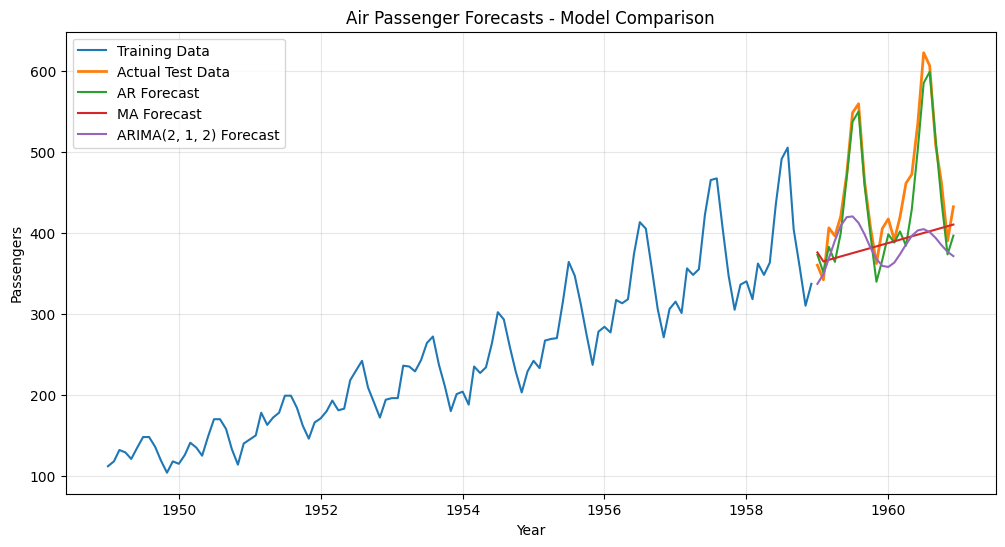

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(train, label="Training Data")
plt.plot(test, label="Actual Test Data", linewidth=2)
plt.plot(ar_pred, label="AR Forecast")
plt.plot(ma_pred, label="MA Forecast")
plt.plot(arima_pred, label=f"ARIMA{best_order} Forecast")
plt.title("Air Passenger Forecasts - Model Comparison")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 16. Residual Diagnostics


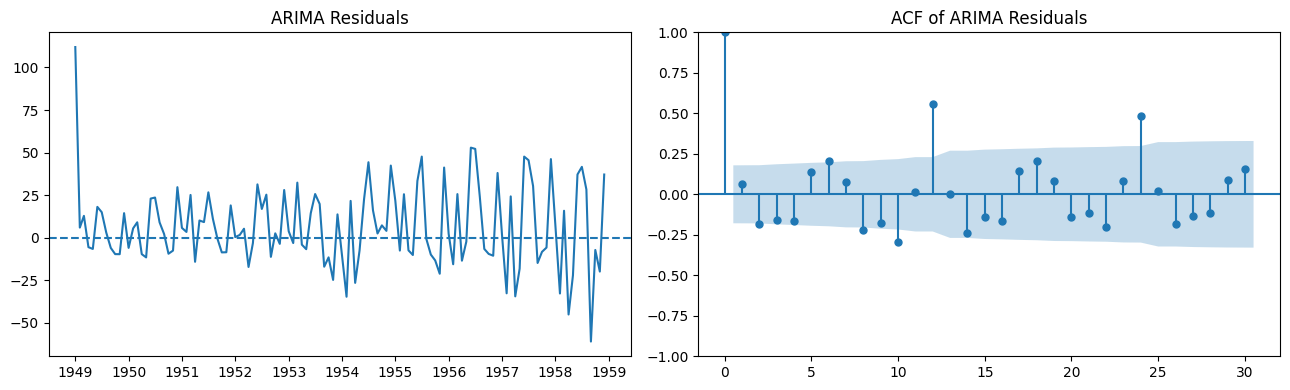

In [16]:
residuals = arima_fit.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(residuals)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("ARIMA Residuals")
plot_acf(residuals.dropna(), lags=30, ax=axes[1])
axes[1].set_title("ACF of ARIMA Residuals")
plt.tight_layout()
plt.show()


## 17. Future Forecasting

The selected ARIMA specification is refitted using the complete dataset and used to forecast the next 12 months.

This project intentionally focuses on **non-seasonal ARIMA**. SARIMA will be treated separately because it explicitly models seasonal structure.


,Forecast
1961-01-01,439.854649
1961-02-01,465.296295
1961-03-01,500.666061
1961-04-01,535.971971
1961-05-01,561.690397
1961-06-01,571.314654
1961-07-01,562.974471
1961-08-01,539.731319
1961-09-01,508.529683
1961-10-01,478.147936


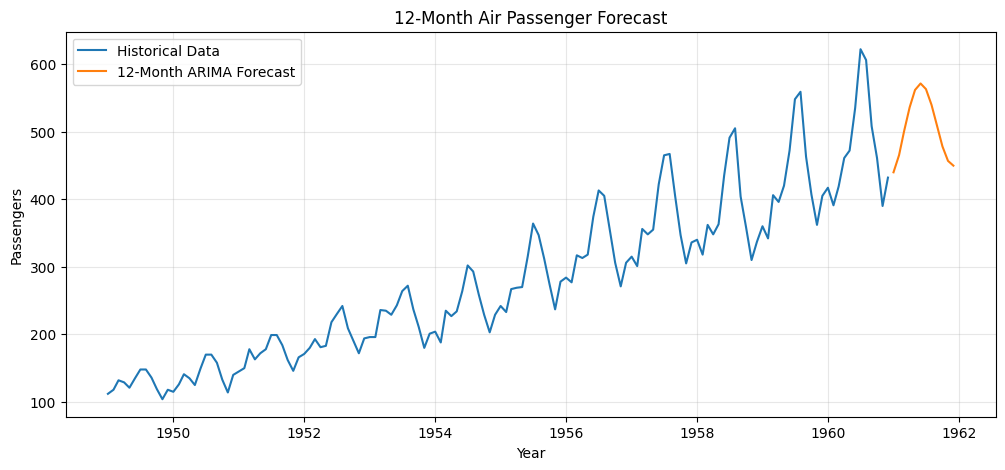

In [17]:
final_fit = ARIMA(series, order=best_order).fit()
future_forecast = final_fit.forecast(steps=12)

future_df = pd.DataFrame({"Forecast": future_forecast})
display(future_df)

plt.figure(figsize=(12, 5))
plt.plot(series, label="Historical Data")
plt.plot(future_forecast, label="12-Month ARIMA Forecast")
plt.title("12-Month Air Passenger Forecast")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 18. Key Findings

- The AirPassengers series contains a clear upward trend and strong recurring temporal structure.
- The original series was non-stationary, with an ADF p-value of **0.991880**.
- First differencing reduced the ADF p-value to **0.054213**, bringing the series close to the conventional 5% stationarity threshold.
- ACF and PACF analysis showed substantial lag dependence in the time series.
- **AR(12)** achieved the best forecasting performance with an MAE of **21.452** and RMSE of **27.073**.
- The **MA(2)** model performed considerably worse, with an MAE of **71.886** and RMSE of **96.545**.
- Among the tested ARIMA specifications, **ARIMA(2,1,2)** had the lowest AIC and was selected for evaluation.
- ARIMA(2,1,2) achieved an MAE of **69.105** and RMSE of **90.703**, substantially worse than AR(12).
- The strong performance of AR(12) indicates that longer lag relationships are important in this monthly passenger series.
- The results also show a limitation of non-seasonal ARIMA for data with strong seasonal behavior, motivating **SARIMA** as a future extension.

## 19. Conclusion

This project demonstrated the progression from basic autoregressive and moving-average models to **ARIMA forecasting** on the AirPassengers time series.

The original series was strongly non-stationary, and first differencing substantially improved its stationarity. ACF and PACF analysis provided insight into the lag relationships present in the data.

Of the evaluated models, **AR(12) performed best**, achieving an MAE of **21.452** and RMSE of **27.073**. The selected non-seasonal **ARIMA(2,1,2)** model produced considerably larger errors, with an MAE of **69.105** and RMSE of **90.703**.

The results indicate that the strong recurring yearly structure in the monthly passenger data is important for forecasting. While ARIMA provides a useful foundation for time-series modeling, explicitly modeling seasonality with **SARIMA** is a logical next step for this dataset.